# 0.9.1 Provincial Network Builder (SciPy Optimized)

This notebook demonstrates the use of **Module 12.1: ProvincialNetworkBuilderSciPy** to create road network graphs and distance matrices using **scipy.sparse.csgraph** for ~10x speedup.

**Key Improvements over 0.9:**
- ⚡ **~10x faster** distance matrix computation using scipy
- Uses scipy.sparse.csgraph.dijkstra() instead of NetworkX loops
- No multiprocessing needed (scipy is already optimized in C/Cython)
- Lower memory footprint with sparse matrix representation

**Performance:**
- NetworkX version (0.9): Minutes for 1000 schools
- SciPy version (0.9.1): Seconds for 1000 schools

**Example Province:** Bulacan (PH03014)

**Outputs:**
1. Distance matrix (CSV)
2. Distance graph (GraphML)
3. Beneficiary graph (GraphML)
4. Summary statistics (JSON)
5. Visualizations

## 0. Setup

In [62]:
import os
import re
import sys
import json
import time
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
from importlib import reload
import matplotlib.pyplot as plt
from pathlib import Path

from shapely.geometry import LineString
from matplotlib.collections import LineCollection

# Add project root to Python path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import config
from config import setup_notebook, get_path
setup_notebook()

✓ Project root: /workspace/project_paaral
✓ Working directory: /workspace/project_paaral
✓ Python path updated


{'project_root': PosixPath('/workspace/project_paaral'),
 'data': PosixPath('/workspace/project_paaral/data'),
 'modules': PosixPath('/workspace/project_paaral/modules'),
 'notebooks': PosixPath('/workspace/project_paaral/notebooks'),
 'output': PosixPath('/workspace/project_paaral/output'),
 'psgc_shapefiles': PosixPath('/workspace/project_paaral/data/philippines-psgc-shapefiles/dist')}

In [13]:
# Import SciPy-optimized builder
from modules import provincial_network_builder_scipy
reload(provincial_network_builder_scipy)

# Import the module
from modules.provincial_network_builder_scipy import ProvincialNetworkBuilderSciPy

## 1. Load Data

Load the validated node tables and beneficiary edges from previous modules.

**Note:** Node tables from Module 11 (NodeTableBuilder) should already include the `adm2_pcode` column via spatial join with PSGC geodata. This column is essential for filtering schools to provinces.

In [14]:
# Load public and private node tables (from Module 11)
public_nodes = gpd.read_file('output/public_nodes_valid.gpkg')
private_nodes = gpd.read_file('output/private_nodes_valid.gpkg')

print(f"Public schools loaded: {len(public_nodes):,}")
print(f"Private schools loaded: {len(private_nodes):,}")

Public schools loaded: 44,899
Private schools loaded: 9,305


In [15]:
# Load beneficiary edges (from Module 11)
beneficiary_edges = pd.read_csv('output/beneficiary_edges_valid.csv')

# Ensure string IDs
beneficiary_edges['school_id_origin'] = beneficiary_edges['school_id_origin'].astype(str)
beneficiary_edges['school_id_destination'] = beneficiary_edges['school_id_destination'].astype(str)

print(f"Beneficiary edges loaded: {len(beneficiary_edges):,}")
print(f"Unique origins: {beneficiary_edges['school_id_origin'].nunique():,}")
print(f"Unique destinations: {beneficiary_edges['school_id_destination'].nunique():,}")

Beneficiary edges loaded: 220,777
Unique origins: 34,411
Unique destinations: 2,955


In [16]:
# Verify adm2_pcode column exists
if 'adm2_pcode' in public_nodes.columns:
    print("✓ adm2_pcode column found in node tables")
    print(f"  Public nodes with adm2_pcode: {public_nodes['adm2_pcode'].notna().sum():,} / {len(public_nodes):,}")
    print(f"  Private nodes with adm2_pcode: {private_nodes['adm2_pcode'].notna().sum():,} / {len(private_nodes):,}")
else:
    print("❌ ERROR: adm2_pcode column missing from node tables!")
    print("   Please regenerate node tables using notebook 0.7 with Module 11.")
    print("   Module 11 automatically adds adm2_pcode via spatial join.")

✓ adm2_pcode column found in node tables
  Public nodes with adm2_pcode: 44,899 / 44,899
  Private nodes with adm2_pcode: 9,305 / 9,305


## 2. Select Province

Filter data to a single province. We'll use **Bulacan (PH03014)** as an example.

In [35]:
OUTPUT = 'output'
ROAD_NETWORKS = 'output/province_road_networks'

road_networks = os.listdir(ROAD_NETWORKS)
print(len(road_networks))

88


In [39]:
# Search
search_key = 'rizal'
pattern = r''+search_key+''

result = [fname for fname in road_networks if re.search(pattern, fname, re.IGNORECASE)]
print(result)
code, name = re.findall(r'(^PH\d{5})_', result[0])[0], re.findall(r'_(.*?)\.geo', result[0])[0]
print(code, name)

['PH04058_rizal.geojsonl']
PH04058 rizal


In [42]:
# Province selection
PROVINCE_CODE = code if code else 'PH03014'
PROVINCE_NAME = name if name else 'bulacan'

# Road network path
ROAD_NETWORK_PATH = f'output/province_road_networks/{PROVINCE_CODE}_{PROVINCE_NAME}.geojsonl'
print(ROAD_NETWORK_PATH)

# Consolidated geodata path (optional)
GEODATA_PATH = 'output/consolidated_geodata_matched.gpkg'

output/province_road_networks/PH04058_rizal.geojsonl


In [43]:
# Filter schools to province
public_bulacan = public_nodes[public_nodes['adm2_pcode'] == PROVINCE_CODE].copy()
private_bulacan = private_nodes[private_nodes['adm2_pcode'] == PROVINCE_CODE].copy()

print(f"Bulacan schools:")
print(f"  Public: {len(public_bulacan):,}")
print(f"  Private: {len(private_bulacan):,}")
print(f"  Total: {len(public_bulacan) + len(private_bulacan):,}")

Bulacan schools:
  Public: 359
  Private: 419
  Total: 778


In [44]:
# Filter beneficiary edges to province
# Include edges where origin OR destination is in Bulacan
bulacan_school_ids = set(public_bulacan['school_id']) | set(private_bulacan['school_id'])

bulacan_edges = beneficiary_edges[
    beneficiary_edges['school_id_origin'].isin(bulacan_school_ids) |
    beneficiary_edges['school_id_destination'].isin(bulacan_school_ids)
].copy()

print(f"\nBulacan beneficiary edges: {len(bulacan_edges):,}")
print(f"  In-province flows: {bulacan_edges[(bulacan_edges['school_id_origin'].isin(bulacan_school_ids)) & (bulacan_edges['school_id_destination'].isin(bulacan_school_ids))].shape[0]:,}")
print(f"  Cross-province flows: {bulacan_edges[~((bulacan_edges['school_id_origin'].isin(bulacan_school_ids)) & (bulacan_edges['school_id_destination'].isin(bulacan_school_ids)))].shape[0]:,}")


Bulacan beneficiary edges: 11,524
  In-province flows: 4,016
  Cross-province flows: 7,508


In [45]:
# Check if road network file exists
if not Path(ROAD_NETWORK_PATH).exists():
    print(f"⚠️  Road network file not found: {ROAD_NETWORK_PATH}")
    print(f"Please ensure Module 9 has been run to extract provincial road networks.")
else:
    print(f"✓ Road network file found: {ROAD_NETWORK_PATH}")

✓ Road network file found: output/province_road_networks/PH04058_rizal.geojsonl


## 3. Initialize Network Builder

Create the ProvincialNetworkBuilderSciPy instance with all required data.

In [46]:
# Initialize builder (scipy-optimized version)
builder = ProvincialNetworkBuilderSciPy(
    province_code=PROVINCE_CODE,
    province_name=PROVINCE_NAME,
    public_nodes_gdf=public_bulacan,
    private_nodes_gdf=private_bulacan,
    beneficiary_edges_df=bulacan_edges,
    road_network_path=ROAD_NETWORK_PATH,
    consolidated_geodata_path=GEODATA_PATH,
    verbose=True
)

INFO:modules.provincial_network_builder_scipy:ProvincialNetworkBuilderSciPy initialized for rizal (PH04058)
INFO:modules.provincial_network_builder_scipy:  Public schools: 359
INFO:modules.provincial_network_builder_scipy:  Private schools: 419
INFO:modules.provincial_network_builder_scipy:  Total schools: 778
INFO:modules.provincial_network_builder_scipy:  Beneficiary edges: 11,524


## 4. Build Complete Network (SciPy-Optimized)

Execute the complete network building workflow:
1. Load road network
2. Snap schools to network
3. Build spatial index
4. **Compute distance matrix (scipy.sparse.csgraph - FAST!)**
5. Build distance and beneficiary graphs

**Note:** No `n_processes` parameter needed - scipy is already optimized!

In [47]:
# Build network (measure time for performance comparison)
# Parameters:
#   buffer_distance_m: Search radius around each school (5km)
#   max_distance_km: Maximum road distance to consider (15km)
#   NO n_processes parameter - scipy doesn't need it!

start_time = time.time()

results = builder.build_complete_network(
    buffer_distance_m=5000,
    max_distance_km=15
)

elapsed_time = time.time() - start_time

print(f"\n⏱️  Total execution time: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")

INFO:modules.provincial_network_builder_scipy:======================================================================
INFO:modules.provincial_network_builder_scipy:Building complete network for rizal (scipy-optimized)
INFO:modules.provincial_network_builder_scipy:======================================================================
INFO:modules.provincial_network_builder_scipy:
[1/5] Loading road network...
INFO:modules.provincial_network_builder_scipy:  Reading GeoJSONL: output/province_road_networks/PH04058_rizal.geojsonl
INFO:modules.provincial_network_builder_scipy:  Loaded 39,497 road segments
INFO:modules.provincial_network_builder_scipy:  Converting to NetworkX graph (EPSG:4326)...
INFO:modules.provincial_network_builder_scipy:  Projecting to EPSG:3123 for distance calculations...
INFO:modules.provincial_network_builder_scipy:  ✓ NetworkX graph: 188,264 nodes, 203,309 edges
INFO:modules.provincial_network_builder_scipy:
[2/5] Snapping schools to road network...
INFO:modules.prov


⏱️  Total execution time: 15.92 seconds (0.27 minutes)


## 5. Analyze Results

Examine the generated distance matrix and graphs.

In [48]:
# Access results
distance_matrix = results['distance_matrix']
distance_graph = results['distance_graph']
beneficiary_graph = results['beneficiary_graph']
road_network = results['road_network']
school_mappings = results['school_mappings']
boundary_nodes = results['boundary_nodes']
statistics = results['statistics']

In [49]:
# Display summary statistics
print("="*70)
print("NETWORK SUMMARY")
print("="*70)
print(json.dumps(statistics, indent=2))

NETWORK SUMMARY
{
  "province_code": "PH04058",
  "province_name": "rizal",
  "total_schools": 778,
  "public_schools": 359,
  "private_schools": 419,
  "road_network": {
    "nodes": 188264,
    "edges": 203309
  },
  "distance_matrix": {
    "shape": [
      778,
      778
    ],
    "valid_pairs": 19715,
    "mean_distance_m": 3984.211985829752
  },
  "distance_graph": {
    "nodes": 778,
    "edges": 19715
  },
  "beneficiary_graph": {
    "nodes": 3960,
    "edges": 11524
  }
}


In [50]:
# Distance matrix statistics
print("\n" + "="*70)
print("DISTANCE MATRIX STATISTICS")
print("="*70)
print(f"Shape: {distance_matrix.shape}")
print(f"\nDistance statistics (meters):")
print(f"  Mean: {distance_matrix.mean().mean():,.0f}m ({distance_matrix.mean().mean()/1000:.1f}km)")
print(f"  Median: {distance_matrix.median().median():,.0f}m ({distance_matrix.median().median()/1000:.1f}km)")
print(f"  Min: {distance_matrix.min().min():,.0f}m ({distance_matrix.min().min()/1000:.1f}km)")
print(f"  Max: {distance_matrix.max().max():,.0f}m ({distance_matrix.max().max()/1000:.1f}km)")
print(f"\nSparsity:")
print(f"  Valid pairs: {distance_matrix.notna().sum().sum():,}")
print(f"  Total pairs: {distance_matrix.size:,}")
print(f"  Density: {distance_matrix.notna().sum().sum() / distance_matrix.size * 100:.2f}%")


DISTANCE MATRIX STATISTICS
Shape: (778, 778)

Distance statistics (meters):
  Mean: 3,984m (4.0km)
  Median: 2,652m (2.7km)
  Min: 0m (0.0km)
  Max: 14,999m (15.0km)

Sparsity:
  Valid pairs: 19,715
  Total pairs: 605,284
  Density: 3.26%


In [51]:
# Sample of distance matrix
print("\nSample of distance matrix (first 5x5):")
display(distance_matrix.iloc[:5, :5])


Sample of distance matrix (first 5x5):


,108460,108463,109307,109310,109311
108460,0.0,NaN,NaN,NaN,NaN
108463,NaN,0.0,NaN,NaN,NaN
109307,NaN,NaN,0.000000,NaN,7674.59405
109310,NaN,NaN,NaN,0.0,NaN
109311,NaN,NaN,5971.464942,NaN,0.00000


In [52]:
# Graph statistics
print("\n" + "="*70)
print("GRAPH STATISTICS")
print("="*70)

print("\nDistance Graph:")
print(f"  Nodes: {distance_graph.number_of_nodes():,}")
print(f"  Edges: {distance_graph.number_of_edges():,}")
print(f"  Density: {nx.density(distance_graph):.6f}")
print(f"  Is connected: {nx.is_weakly_connected(distance_graph)}")

print("\nBeneficiary Graph:")
print(f"  Nodes: {beneficiary_graph.number_of_nodes():,}")
print(f"  Edges: {beneficiary_graph.number_of_edges():,}")
print(f"  Density: {nx.density(beneficiary_graph):.6f}")
print(f"  Total beneficiaries: {sum(nx.get_edge_attributes(beneficiary_graph, 'beneficiary_count').values()):,}")


GRAPH STATISTICS

Distance Graph:
  Nodes: 778
  Edges: 19,715
  Density: 0.032613
  Is connected: False

Beneficiary Graph:
  Nodes: 3,960
  Edges: 11,524
  Density: 0.000735
  Total beneficiaries: 51,236


## 6. Visualizations

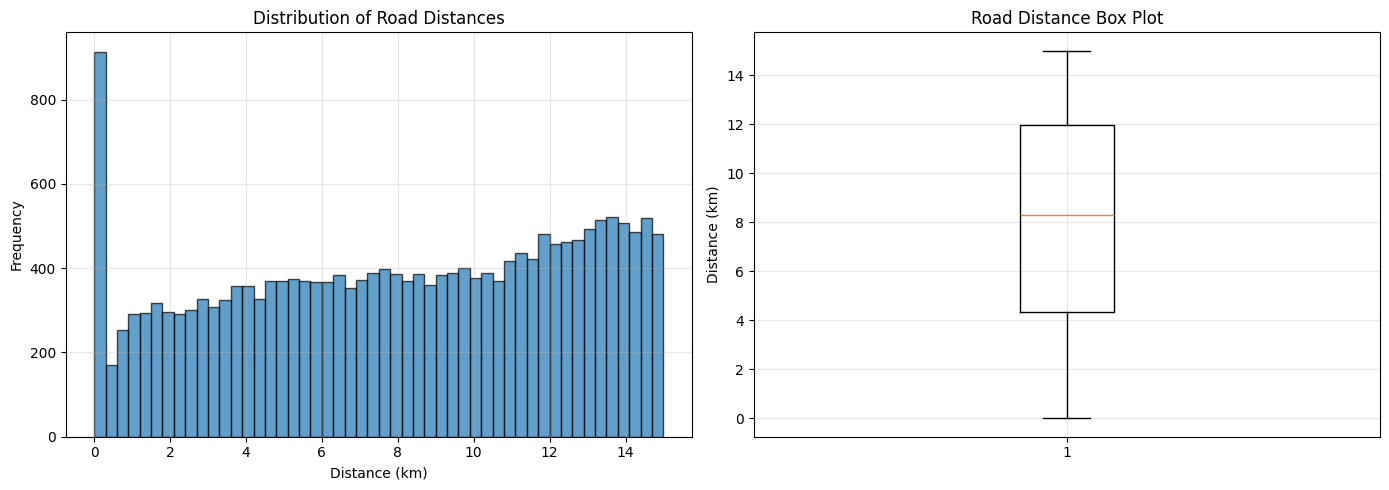

In [53]:
# Distance distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
distances_flat = distance_matrix.values.flatten()
distances_flat = distances_flat[~np.isnan(distances_flat)]

axes[0].hist(distances_flat / 1000, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Road Distances')
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot(distances_flat / 1000, vert=True)
axes[1].set_ylabel('Distance (km)')
axes[1].set_title('Road Distance Box Plot')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

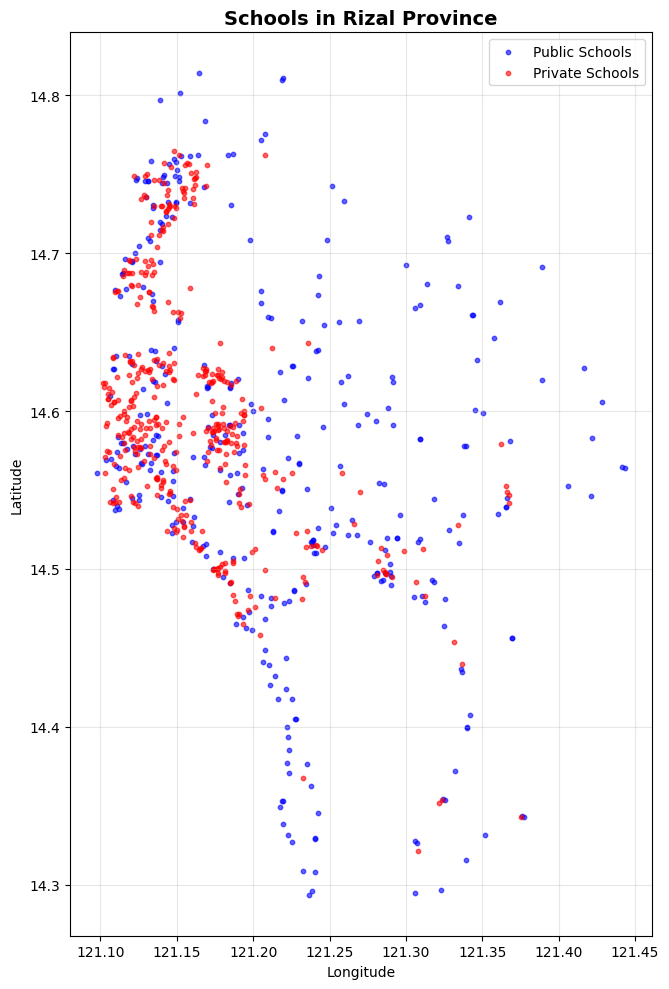

In [54]:
# School locations
fig, ax = plt.subplots(figsize=(12, 10))

# Plot schools
public_bulacan.plot(ax=ax, color='blue', markersize=10, alpha=0.6, label='Public Schools')
private_bulacan.plot(ax=ax, color='red', markersize=10, alpha=0.6, label='Private Schools')

ax.set_title(f'Schools in {PROVINCE_NAME.title()} Province', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

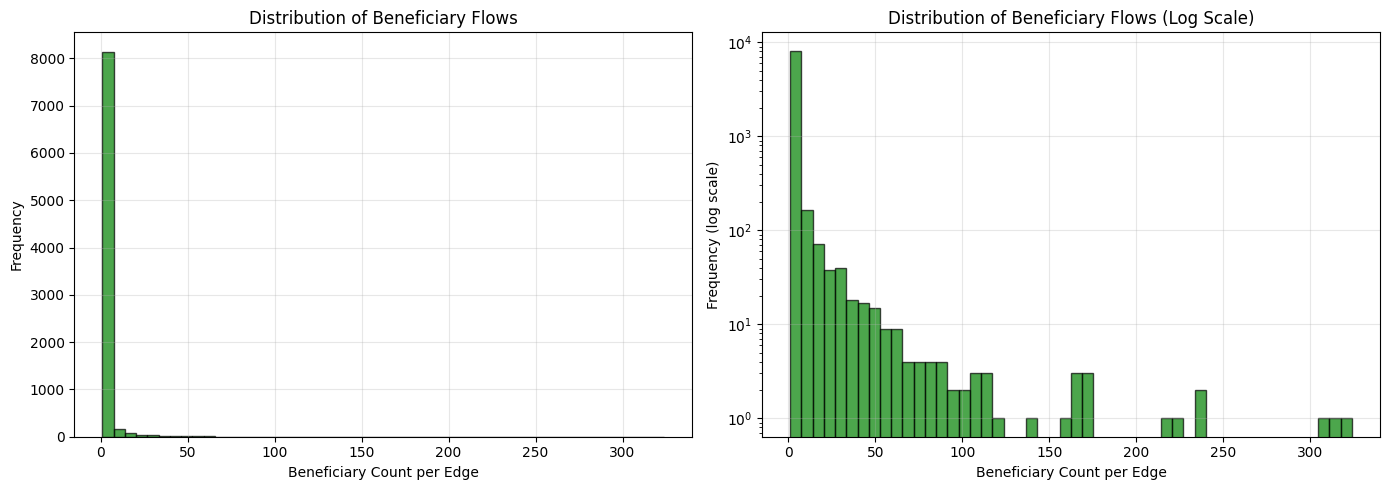

In [30]:
# Beneficiary flow statistics
beneficiary_counts = nx.get_edge_attributes(beneficiary_graph, 'beneficiary_count')
beneficiary_values = list(beneficiary_counts.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(beneficiary_values, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0].set_xlabel('Beneficiary Count per Edge')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Beneficiary Flows')
axes[0].grid(alpha=0.3)

# Log scale
axes[1].hist(beneficiary_values, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Beneficiary Count per Edge')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_title('Distribution of Beneficiary Flows (Log Scale)')
axes[1].set_yscale('log')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 6.4 Network Verification Visualizations

Verify the road network and school connections by visualizing:
1. **Base overlay**: Province boundary + Road network + School locations
2. **School connections**: Same as above + highlighted edges between schools <3km apart

#### Viz 1

Loading province boundary for PH04058...
✓ Province boundary loaded: Rizal

Loading road network from output/province_road_networks/PH04058_rizal.geojsonl...
✓ Road network loaded: 39,497 road segments


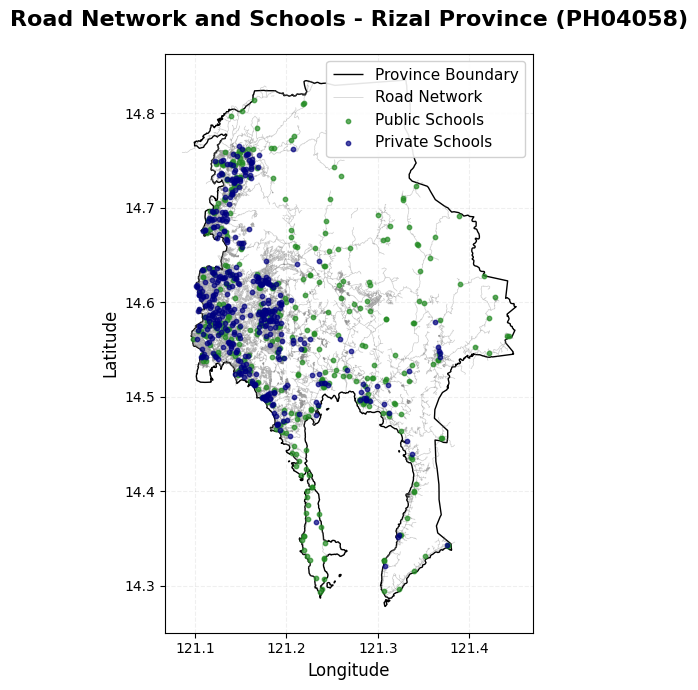


✓ Visualization 1 complete
  Province boundary: Yes
  Road segments: 39,497
  Public schools: 359
  Private schools: 419
CPU times: user 3.14 s, sys: 950 ms, total: 4.09 s
Wall time: 13.1 s


In [56]:
%%time
# Visualization 1: Province boundary + Road network + Schools

# Load province boundary
print(f"Loading province boundary for {PROVINCE_CODE}...")
geodata = gpd.read_file(GEODATA_PATH)
province_boundary = geodata[geodata['adm2_pcode'] == PROVINCE_CODE].copy()

if len(province_boundary) == 0:
    print(f"⚠️  Warning: No boundary found for {PROVINCE_CODE}")
else:
    # Dissolve to single polygon if multiple geometries
    province_boundary = province_boundary.dissolve()
    print(f"✓ Province boundary loaded: {province_boundary.iloc[0]['adm2_en']}")

# Load road network
print(f"\nLoading road network from {ROAD_NETWORK_PATH}...")
road_network_gdf = gpd.read_file(ROAD_NETWORK_PATH)
print(f"✓ Road network loaded: {len(road_network_gdf):,} road segments")

# Create figure
fig_scaler = 0.5 # default is 1.0
fig, ax = plt.subplots(figsize=(16*fig_scaler, 14*fig_scaler))

# Plot province boundary (base layer)
if len(province_boundary) > 0:
    province_boundary.boundary.plot(ax=ax, color='black', linewidth=1, label='Province Boundary')

# Plot road network (gray, thin lines)
road_network_gdf.plot(ax=ax, color='gray', linewidth=0.5, alpha=0.4, label='Road Network')

# Plot schools (color-coded by sector)
public_bulacan.plot(ax=ax, color='forestgreen', markersize=10, alpha=0.7, label='Public Schools', zorder=3)
private_bulacan.plot(ax=ax, color='navy', markersize=10, alpha=0.7, label='Private Schools', zorder=3)

# Styling
ax.set_title(f'Road Network and Schools - {PROVINCE_NAME.title()} Province ({PROVINCE_CODE})', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.grid(alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

print(f"\n✓ Visualization 1 complete")
print(f"  Province boundary: {'Yes' if len(province_boundary) > 0 else 'No'}")
print(f"  Road segments: {len(road_network_gdf):,}")
print(f"  Public schools: {len(public_bulacan):,}")
print(f"  Private schools: {len(private_bulacan):,}")

#### Viz 2

In [57]:
# Visualization 2: Same as Visualization 1 + School connections <3km
from shapely.geometry import LineString

# Filter distance matrix for schools <3km apart
print("Extracting school connections <3km...")
connections = []

# Stack distance matrix to get all pairs
dist_pairs = distance_matrix.stack()
# Filter for distances < 3000m and > 0 (exclude self-connections)
nearby_schools = dist_pairs[(dist_pairs < 3000) & (dist_pairs > 0)]
print(f"✓ Found {len(nearby_schools):,} school pairs within 3km")

# Create GeoDataFrame of connection lines
print("\nCreating connection geometries...")
all_schools = pd.concat([public_bulacan, private_bulacan])

connection_geoms = []
for (origin_id, dest_id), distance in nearby_schools.items():
    # Get coordinates for both schools
    origin_row = all_schools[all_schools['school_id'] == origin_id]
    dest_row = all_schools[all_schools['school_id'] == dest_id]
    
    if len(origin_row) > 0 and len(dest_row) > 0:
        origin_geom = origin_row.iloc[0].geometry
        dest_geom = dest_row.iloc[0].geometry
        
        # Create LineString connecting the two schools
        line = LineString([origin_geom.coords[0], dest_geom.coords[0]])
        connection_geoms.append({
            'origin_id': origin_id,
            'dest_id': dest_id,
            'distance_m': distance,
            'geometry': line
        })

connections_gdf = gpd.GeoDataFrame(connection_geoms, crs='EPSG:4326')
print(f"✓ Created {len(connections_gdf):,} connection lines")

Extracting school connections <3km...
✓ Found 2,653 school pairs within 3km

Creating connection geometries...
✓ Created 2,653 connection lines


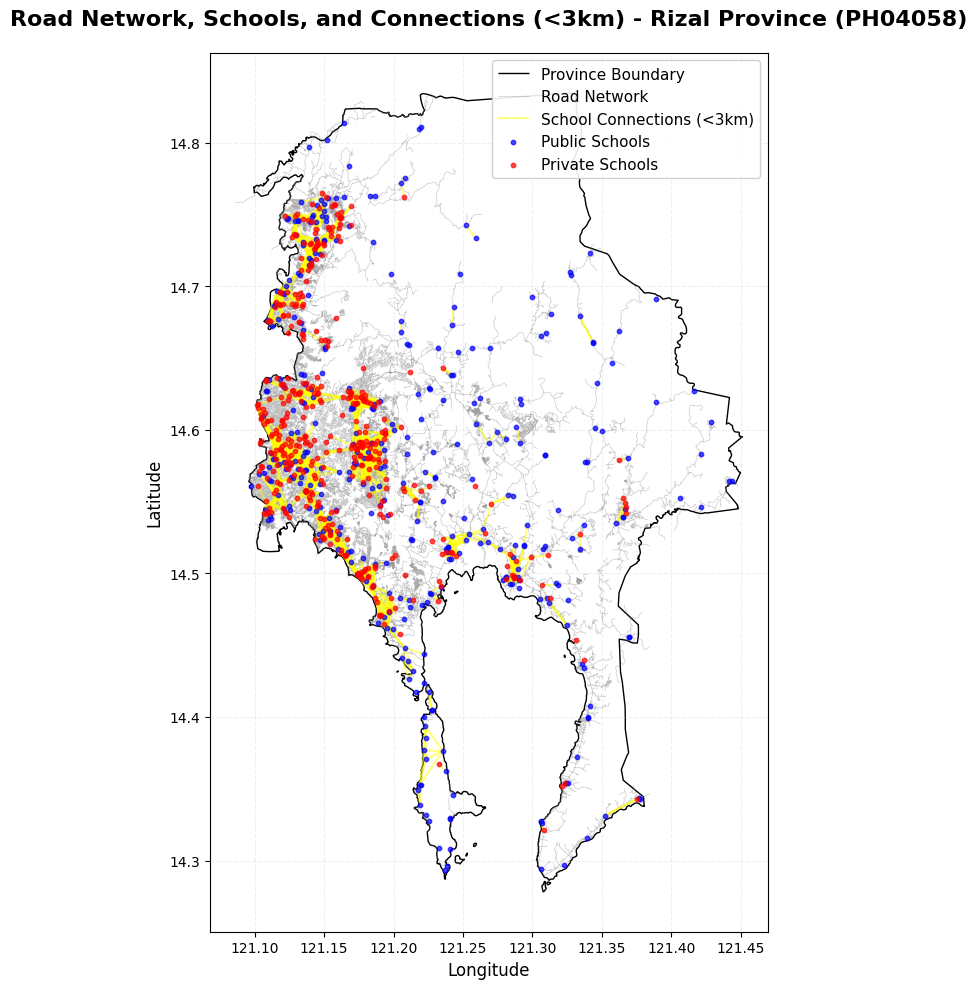


✓ Visualization 2 complete
  Province boundary: Yes
  Road segments: 39,497
  Public schools: 359
  Private schools: 419
  School connections (<3km): 2,653


In [58]:
# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

# Plot province boundary (base layer)
if len(province_boundary) > 0:
    province_boundary.boundary.plot(ax=ax, color='black', linewidth=1, label='Province Boundary', zorder=1)

# Plot road network (gray, thin lines)
road_network_gdf.plot(ax=ax, color='gray', linewidth=0.5, alpha=0.4, label='Road Network', zorder=2)

# Plot school connections <3km (green/yellow, semi-transparent)
connections_gdf.plot(ax=ax, color='yellow', linewidth=1.5, alpha=0.5, label='School Connections (<3km)', zorder=3)

# Plot schools (color-coded by sector)
public_bulacan.plot(ax=ax, color='blue', markersize=10, alpha=0.7, label='Public Schools', zorder=4)
private_bulacan.plot(ax=ax, color='red', markersize=10, alpha=0.7, label='Private Schools', zorder=4)

# Styling
ax.set_title(f'Road Network, Schools, and Connections (<3km) - {PROVINCE_NAME.title()} Province ({PROVINCE_CODE})', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.grid(alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

print(f"\n✓ Visualization 2 complete")
print(f"  Province boundary: {'Yes' if len(province_boundary) > 0 else 'No'}")
print(f"  Road segments: {len(road_network_gdf):,}")
print(f"  Public schools: {len(public_bulacan):,}")
print(f"  Private schools: {len(private_bulacan):,}")
print(f"  School connections (<3km): {len(connections_gdf):,}")

#### Viz 3

In [60]:
# Visualization 3: Beneficiary Flow Connections
# from shapely.geometry import LineString
# import matplotlib.pyplot as plt

# Filter to in-province flows only (both origin and destination in province)
print("Extracting in-province beneficiary flows...")
bulacan_school_ids_set = set(public_bulacan['school_id']) | set(private_bulacan['school_id'])

in_province_flows = bulacan_edges[
    bulacan_edges['school_id_origin'].isin(bulacan_school_ids_set) &
    bulacan_edges['school_id_destination'].isin(bulacan_school_ids_set)
].copy()

print(f"✓ In-province flows: {len(in_province_flows):,}")
print(f"  External flows excluded: {len(bulacan_edges) - len(in_province_flows):,}")

# Statistics on beneficiary counts
print(f"\nBeneficiary count statistics:")
print(f"  Min: {in_province_flows['beneficiary_count'].min()}")
print(f"  Max: {in_province_flows['beneficiary_count'].max()}")
print(f"  Mean: {in_province_flows['beneficiary_count'].mean():.1f}")
print(f"  Median: {in_province_flows['beneficiary_count'].median():.1f}")

# Top 5 flows by beneficiary count
top_flows = in_province_flows.nlargest(5, 'beneficiary_count')
print(f"\nTop 5 flows by beneficiary count:")
for idx, row in top_flows.iterrows():
    print(f"  {row['school_id_origin']} → {row['school_id_destination']}: {row['beneficiary_count']} students")

# Create GeoDataFrame of beneficiary flow lines
print(f"\nCreating beneficiary flow geometries...")
all_schools = pd.concat([public_bulacan, private_bulacan])

flow_geoms = []
skipped = 0

for idx, row in in_province_flows.iterrows():
    origin_id = row['school_id_origin']
    dest_id = row['school_id_destination']
    beneficiary_count = row['beneficiary_count']
    
    # Get coordinates for both schools
    origin_row = all_schools[all_schools['school_id'] == origin_id]
    dest_row = all_schools[all_schools['school_id'] == dest_id]
    
    if len(origin_row) > 0 and len(dest_row) > 0:
        origin_geom = origin_row.iloc[0].geometry
        dest_geom = dest_row.iloc[0].geometry
        
        # Create LineString from origin to destination
        line = LineString([origin_geom.coords[0], dest_geom.coords[0]])
        flow_geoms.append({
            'origin_id': origin_id,
            'dest_id': dest_id,
            'beneficiary_count': beneficiary_count,
            'geometry': line
        })
    else:
        skipped += 1

flows_gdf = gpd.GeoDataFrame(flow_geoms, crs='EPSG:4326')
print(f"✓ Created {len(flows_gdf):,} flow lines")
if skipped > 0:
    print(f"  ⚠ Skipped {skipped} flows (missing coordinates)")

# Normalize line widths based on beneficiary count (log scale for better visualization)
# Map beneficiary counts to line width range: 0.3 to 3.0
min_width = 0.3
max_width = 3.0
flows_gdf['line_width'] = np.log1p(flows_gdf['beneficiary_count'])  # log1p = log(1 + x)
width_min = flows_gdf['line_width'].min()
width_max = flows_gdf['line_width'].max()
flows_gdf['line_width'] = min_width + (flows_gdf['line_width'] - width_min) / (width_max - width_min) * (max_width - min_width)

Extracting in-province beneficiary flows...
✓ In-province flows: 4,016
  External flows excluded: 7,508

Beneficiary count statistics:
  Min: 1
  Max: 906
  Mean: 9.8
  Median: 2.0

Top 5 flows by beneficiary count:
  402928 → 402928: 906 students
  403006 → 403006: 877 students
  109327 → 402964: 790 students
  403139 → 403139: 526 students
  403097 → 403097: 485 students

Creating beneficiary flow geometries...
✓ Created 4,016 flow lines


Plotting beneficiary flows using LineCollection...
✓ Plotted 4,016 flow lines in single batch


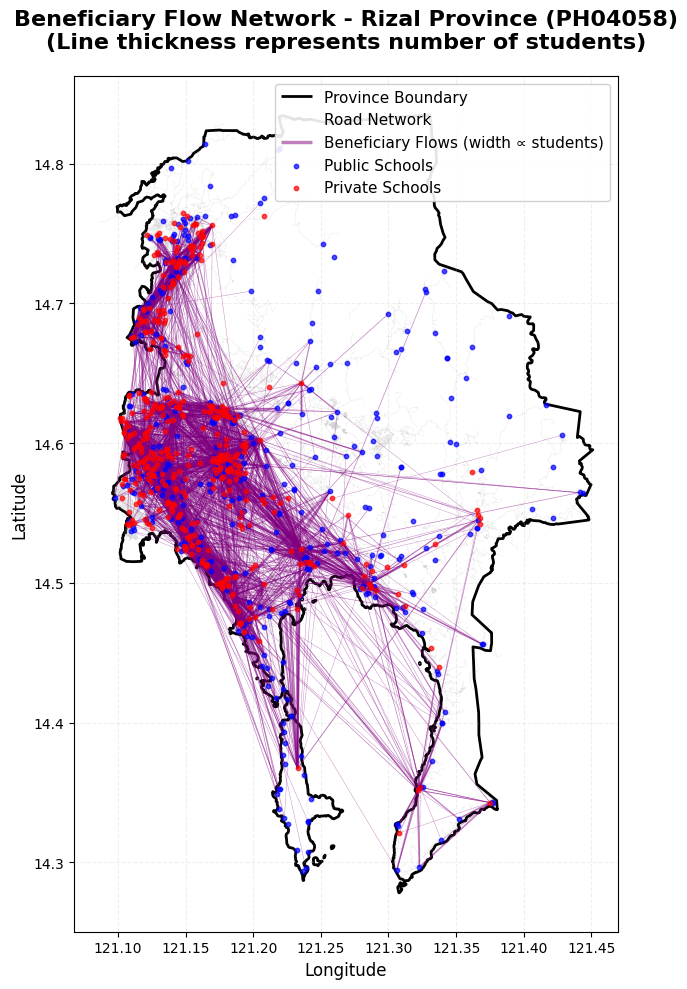


✓ Visualization 3 complete
  Province boundary: Yes
  Road segments: 39,497
  Public schools: 359
  Private schools: 419
  Beneficiary flows: 4,016
  Beneficiary count range: 1 - 906 students
CPU times: user 1.13 s, sys: 24.1 ms, total: 1.16 s
Wall time: 1.15 s


In [63]:
%%time
# Create figure with optimized LineCollection plotting
# from matplotlib.collections import LineCollection

fig, ax = plt.subplots(figsize=(12, 10))

# Plot province boundary (base layer)
if len(province_boundary) > 0:
    province_boundary.boundary.plot(ax=ax, color='black', linewidth=2, label='Province Boundary', zorder=1)

# Plot road network (gray, very thin - just for context)
road_network_gdf.plot(ax=ax, color='gray', linewidth=0.3, alpha=0.2, label='Road Network', zorder=2)

# Plot beneficiary flows using LineCollection (FAST - single call for all 4,016 lines!)
print("Plotting beneficiary flows using LineCollection...")
segments = [list(geom.coords) for geom in flows_gdf.geometry]
widths = flows_gdf['line_width'].values

lc = LineCollection(
    segments, 
    linewidths=widths,
    colors='purple',
    alpha=0.5,
    zorder=3,
    label='Beneficiary Flows (width ∝ students)'
)
ax.add_collection(lc)
print(f"✓ Plotted {len(segments):,} flow lines in single batch")

# Plot schools (color-coded by sector)
public_bulacan.plot(ax=ax, color='blue', markersize=10, alpha=0.7, label='Public Schools', zorder=4)
private_bulacan.plot(ax=ax, color='red', markersize=10, alpha=0.7, label='Private Schools', zorder=4)

# Styling
ax.set_title(f'Beneficiary Flow Network - {PROVINCE_NAME.title()} Province ({PROVINCE_CODE})\n(Line thickness represents number of students)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.grid(alpha=0.2, linestyle='--')

# Auto-scale axes to data
ax.autoscale()

plt.tight_layout()
plt.show()

print(f"\n✓ Visualization 3 complete")
print(f"  Province boundary: {'Yes' if len(province_boundary) > 0 else 'No'}")
print(f"  Road segments: {len(road_network_gdf):,}")
print(f"  Public schools: {len(public_bulacan):,}")
print(f"  Private schools: {len(private_bulacan):,}")
print(f"  Beneficiary flows: {len(flows_gdf):,}")
print(f"  Beneficiary count range: {in_province_flows['beneficiary_count'].min()} - {in_province_flows['beneficiary_count'].max()} students")

#### Viz 4: Interactive Network (Plotly)

In [68]:
# Configuration dictionary for granular control over visual elements
viz_config = {
    'figure': {
        'width': 1200,
        'height': 800,
        'title': f'Interactive Beneficiary Flow Network - {PROVINCE_NAME.title()} ({PROVINCE_CODE})',
        'title_font_size': 14
    },
    'schools': {
        'dest_jhs': {
            'size': 14, 
            'color': 'crimson', 
            'symbol': 'diamond',
            'opacity': 0.85,
            'name': 'Destination JHS',
            'line_width': 1,
            'line_color': 'darkred'
        },
        'origin_only': {
            'size': 10, 
            'color': 'dodgerblue', 
            'symbol': 'circle',
            'opacity': 0.75,
            'name': 'Origin Schools',
            'line_width': 0.5,
            'line_color': 'navy'
        },
        'both': {
            'size': 12,
            'color': 'forestgreen',
            'symbol': 'square',
            'opacity': 0.8,
            'name': 'Both In/Out',
            'line_width': 1,
            'line_color': 'darkgreen'
        },
        'no_edges': {
            'size': 6, 
            'color': 'lightgray', 
            'symbol': 'circle',
            'opacity': 0.3,
            'name': 'No Flows (Greyed Out)',
            'line_width': 0,
            'line_color': 'gray'
        }
    },
    'road_network': {
        'width': 0.4, 
        'color': 'gray', 
        'opacity': 0.12,
        'sample_rate': 0.3  # Show 30% of roads if >10k segments (for performance)
    },
    'flows': {
        'color': 'purple', 
        'opacity': 0.35,
        'width_min': 0.5,
        'width_max': 3.5
    },
    'boundary': {
        'width': 2.5, 
        'color': 'black',
        'opacity': 0.9
    }
}

print("✓ Configuration dictionary created")
print(f"  Figure size: {viz_config['figure']['width']} × {viz_config['figure']['height']}")
print(f"  Road network sample rate: {viz_config['road_network']['sample_rate']*100:.0f}%")
print(f"  School marker sizes: Dest JHS={viz_config['schools']['dest_jhs']['size']}, Origin={viz_config['schools']['origin_only']['size']}")

✓ Configuration dictionary created
  Figure size: 1200 × 800
  Road network sample rate: 30%
  School marker sizes: Dest JHS=14, Origin=10


In [69]:
# Classify schools efficiently (vectorized approach)
print("Classifying schools by role in beneficiary network...")

# Reuse flows_gdf from Viz 3 - calculate in/out totals
in_flow_totals = flows_gdf.groupby('dest_id')['beneficiary_count'].sum().to_dict()
out_flow_totals = flows_gdf.groupby('origin_id')['beneficiary_count'].sum().to_dict()

# Get in/out edge counts from beneficiary_graph
in_counts = dict(beneficiary_graph.in_degree())
out_counts = dict(beneficiary_graph.out_degree())

# Combine all schools and add classification columns
all_schools_viz4 = pd.concat([public_bulacan, private_bulacan], ignore_index=True)
all_schools_viz4['in_count'] = all_schools_viz4['school_id'].map(in_counts).fillna(0).astype(int)
all_schools_viz4['out_count'] = all_schools_viz4['school_id'].map(out_counts).fillna(0).astype(int)
all_schools_viz4['in_beneficiaries'] = all_schools_viz4['school_id'].map(in_flow_totals).fillna(0).astype(int)
all_schools_viz4['out_beneficiaries'] = all_schools_viz4['school_id'].map(out_flow_totals).fillna(0).astype(int)

# Check if 'offers_jhs' column exists, if not create based on available data
if 'offers_jhs' not in all_schools_viz4.columns:
    print("  ⚠ 'offers_jhs' column not found, using heuristic based on sector")
    # Assume all public schools offer JHS, check private school names/other indicators
    all_schools_viz4['offers_jhs'] = all_schools_viz4['sector'] == 'Public'
else:
    # Ensure boolean type
    all_schools_viz4['offers_jhs'] = all_schools_viz4['offers_jhs'].fillna(False).astype(bool)

# Classify into 4 categories (mutually exclusive for clear visualization)
dest_jhs_mask = (all_schools_viz4['in_count'] > 0) & (all_schools_viz4['offers_jhs'] == True)
origin_only_mask = (all_schools_viz4['out_count'] > 0) & (all_schools_viz4['in_count'] == 0)
both_mask = (all_schools_viz4['in_count'] > 0) & (all_schools_viz4['out_count'] > 0) & (~dest_jhs_mask)
no_edges_mask = (all_schools_viz4['in_count'] == 0) & (all_schools_viz4['out_count'] == 0)

dest_jhs = all_schools_viz4[dest_jhs_mask].copy()
origin_only = all_schools_viz4[origin_only_mask].copy()
both_in_out = all_schools_viz4[both_mask].copy()
no_edges_schools = all_schools_viz4[no_edges_mask].copy()

print(f"✓ School classification complete:")
print(f"  Destination JHS (diamond): {len(dest_jhs)} schools")
print(f"  Origin only (circle): {len(origin_only)} schools")
print(f"  Both in/out (square): {len(both_in_out)} schools")
print(f"  No edges (greyed circle): {len(no_edges_schools)} schools")
print(f"  Total: {len(all_schools_viz4)} schools")

Classifying schools by role in beneficiary network...
✓ School classification complete:
  Destination JHS (diamond): 0 schools
  Origin only (circle): 465 schools
  Both in/out (square): 104 schools
  No edges (greyed circle): 203 schools
  Total: 778 schools


In [ ]:
%%time
# Create interactive Plotly visualization
import plotly.graph_objects as go
from shapely.geometry import Polygon, MultiPolygon

print("Creating interactive Plotly visualization...")

fig = go.Figure()

# Layer 1: Province boundary (handle both Polygon and MultiPolygon)
if len(province_boundary) > 0:
    print("  Adding province boundary...")
    geom = province_boundary.iloc[0].geometry
    
    # Handle MultiPolygon (multiple polygons) vs Polygon (single polygon)
    if isinstance(geom, MultiPolygon):
        # MultiPolygon - plot each polygon's exterior
        for poly in geom.geoms:
            boundary_coords = list(poly.exterior.coords)
            boundary_lons = [coord[0] for coord in boundary_coords]
            boundary_lats = [coord[1] for coord in boundary_coords]
            
            fig.add_trace(go.Scatter(
                x=boundary_lons,
                y=boundary_lats,
                mode='lines',
                line=dict(color=viz_config['boundary']['color'], width=viz_config['boundary']['width']),
                opacity=viz_config['boundary']['opacity'],
                name='Province Boundary',
                showlegend=True,
                hoverinfo='skip'
            ))
    elif isinstance(geom, Polygon):
        # Single Polygon
        boundary_coords = list(geom.exterior.coords)
        boundary_lons = [coord[0] for coord in boundary_coords]
        boundary_lats = [coord[1] for coord in boundary_coords]
        
        fig.add_trace(go.Scatter(
            x=boundary_lons,
            y=boundary_lats,
            mode='lines',
            line=dict(color=viz_config['boundary']['color'], width=viz_config['boundary']['width']),
            opacity=viz_config['boundary']['opacity'],
            name='Province Boundary',
            showlegend=True,
            hoverinfo='skip'
        ))

# Layer 2: Road network (sampled for performance)
print("  Adding road network...")
sample_rate = viz_config['road_network']['sample_rate']
if len(road_network_gdf) > 10000 and sample_rate < 1.0:
    road_sample = road_network_gdf.sample(frac=sample_rate, random_state=42)
    print(f"    Sampled {len(road_sample):,} / {len(road_network_gdf):,} roads ({sample_rate*100:.0f}%)")
else:
    road_sample = road_network_gdf
    print(f"    Using all {len(road_sample):,} roads")

# Plot roads as individual line segments
for idx, row in road_sample.iterrows():
    coords = list(row.geometry.coords)
    lons = [c[0] for c in coords]
    lats = [c[1] for c in coords]
    fig.add_trace(go.Scatter(
        x=lons,
        y=lats,
        mode='lines',
        line=dict(color=viz_config['road_network']['color'], width=viz_config['road_network']['width']),
        opacity=viz_config['road_network']['opacity'],
        showlegend=False,
        hoverinfo='skip'
    ))

# Layer 3: Beneficiary flows
print("  Adding beneficiary flows...")
for idx, row in flows_gdf.iterrows():
    coords = list(row.geometry.coords)
    lons = [coords[0][0], coords[1][0]]
    lats = [coords[0][1], coords[1][1]]
    
    fig.add_trace(go.Scatter(
        x=lons,
        y=lats,
        mode='lines',
        line=dict(color=viz_config['flows']['color'], width=row['line_width']),
        opacity=viz_config['flows']['opacity'],
        showlegend=False,
        hovertext=f"{row['origin_id']} → {row['dest_id']}<br>Beneficiaries: {row['beneficiary_count']}",
        hoverinfo='text'
    ))
print(f"    Added {len(flows_gdf):,} flow lines")

# Helper function to add school trace
def add_school_trace(schools_df, config_key, config):
    if len(schools_df) == 0:
        return
    
    # Extract coordinates
    lons = schools_df.geometry.x.values
    lats = schools_df.geometry.y.values
    
    # Prepare hover data
    hover_text = []
    for idx, row in schools_df.iterrows():
        school_name = row.get('school_name', 'Unknown')
        school_id = row['school_id']
        sector = row.get('sector', 'Unknown')
        in_edges = row['in_count']
        in_students = row['in_beneficiaries']
        out_edges = row['out_count']
        out_students = row['out_beneficiaries']
        
        text = (
            f"<b>{school_name}</b><br>"
            f"ID: {school_id}<br>"
            f"Sector: {sector}<br>"
            f"<br>"
            f"Incoming: {in_edges} edges, {in_students} students<br>"
            f"Outgoing: {out_edges} edges, {out_students} students"
        )
        hover_text.append(text)
    
    # Add trace
    fig.add_trace(go.Scatter(
        x=lons,
        y=lats,
        mode='markers',
        marker=dict(
            size=config['size'],
            color=config['color'],
            symbol=config['symbol'],
            opacity=config['opacity'],
            line=dict(width=config['line_width'], color=config['line_color'])
        ),
        name=config['name'],
        showlegend=True,
        hovertext=hover_text,
        hoverinfo='text'
    ))

# Layer 4-7: School markers (4 categories)
print("  Adding school markers...")
add_school_trace(no_edges_schools, 'no_edges', viz_config['schools']['no_edges'])
add_school_trace(origin_only, 'origin_only', viz_config['schools']['origin_only'])
add_school_trace(both_in_out, 'both', viz_config['schools']['both'])
add_school_trace(dest_jhs, 'dest_jhs', viz_config['schools']['dest_jhs'])

# Layout configuration
fig.update_layout(
    title=dict(
        text=viz_config['figure']['title'],
        font=dict(size=viz_config['figure']['title_font_size'])
    ),
    width=viz_config['figure']['width'],
    height=viz_config['figure']['height'],
    xaxis=dict(title='Longitude', showgrid=True, gridcolor='lightgray'),
    yaxis=dict(title='Latitude', showgrid=True, gridcolor='lightgray', scaleanchor='x', scaleratio=1),
    hovermode='closest',
    plot_bgcolor='white',
    legend=dict(x=1.02, y=1, xanchor='left', yanchor='top')
)

print("✓ Interactive visualization complete!")
print(f"  Total traces: {len(fig.data)}")
print(f"  Hover over schools to see details")
print(f"  Hover over purple lines to see beneficiary flows")

fig.show()

In [71]:
# Save interactive figure as HTML file
output_file = f'output/viz4_interactive_network_{PROVINCE_CODE}_{PROVINCE_NAME}.html'
fig.write_html(output_file)

print(f"✓ Interactive visualization saved to: {output_file}")
print(f"  Open this file in your browser to view the interactive plot")

✓ Interactive visualization saved to: output/viz4_interactive_network_PH04058_rizal.html
  Open this file in your browser to view the interactive plot


## 7. Export Results

Export all results to the output directory for use in regional merging or further analysis.

In [ ]:
# # Export all results
# output_dir = Path('output/provincial_networks_scipy')
# output_dir.mkdir(parents=True, exist_ok=True)

# builder.export_all(str(output_dir))

# print("\n" + "="*70)
# print("EXPORTED FILES")
# print("="*70)
# for file in sorted(output_dir.glob(f"{PROVINCE_CODE}_{PROVINCE_NAME}*")):
#     print(f"  {file.name}")

## 8. Graph Analysis Examples

Demonstrate basic NetworkX graph analysis operations.

In [31]:
# Example 1: Find shortest path between two schools
# Pick two random schools
sample_schools = distance_matrix.index[:2].tolist()
if len(sample_schools) >= 2:
    origin = sample_schools[0]
    destination = sample_schools[1]
    
    if nx.has_path(distance_graph, origin, destination):
        path = nx.shortest_path(distance_graph, origin, destination, weight='distance_m')
        path_length = nx.shortest_path_length(distance_graph, origin, destination, weight='distance_m')
        
        print("Example Shortest Path:")
        print(f"  From: {origin}")
        print(f"  To: {destination}")
        print(f"  Path length: {path_length:,.0f}m ({path_length/1000:.1f}km)")
        print(f"  Path: {' → '.join(path[:5])}..." if len(path) > 5 else f"  Path: {' → '.join(path)}")

In [32]:
# Example 2: Degree centrality in beneficiary graph
in_degree = dict(beneficiary_graph.in_degree())
out_degree = dict(beneficiary_graph.out_degree())

# Top 5 schools by incoming beneficiary flows (destinations)
top_destinations = sorted(in_degree.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 Destination Schools (by incoming edge count):")
for school_id, degree in top_destinations:
    print(f"  {school_id}: {degree} incoming edges")

# Top 5 schools by outgoing beneficiary flows (origins)
top_origins = sorted(out_degree.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 Origin Schools (by outgoing edge count):")
for school_id, degree in top_origins:
    print(f"  {school_id}: {degree} outgoing edges")


Top 5 Destination Schools (by incoming edge count):
  401404: 466 incoming edges
  401439: 365 incoming edges
  408836: 193 incoming edges
  400729: 182 incoming edges
  401415: 181 incoming edges

Top 5 Origin Schools (by outgoing edge count):
  107158: 66 outgoing edges
  107165: 51 outgoing edges
  401487: 46 outgoing edges
  107154: 42 outgoing edges
  107161: 42 outgoing edges


In [33]:
# Example 3: Total beneficiaries by school
# Sum beneficiary counts for each school
beneficiary_in = {}
beneficiary_out = {}

for origin, dest, data in beneficiary_graph.edges(data=True):
    count = data.get('beneficiary_count', 0)
    beneficiary_out[origin] = beneficiary_out.get(origin, 0) + count
    beneficiary_in[dest] = beneficiary_in.get(dest, 0) + count

# Top 5 by total beneficiaries received
top_receivers = sorted(beneficiary_in.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 Schools by Total Beneficiaries Received:")
for school_id, count in top_receivers:
    print(f"  {school_id}: {count:,} beneficiaries")

# Top 5 by total beneficiaries sent
top_senders = sorted(beneficiary_out.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 Schools by Total Beneficiaries Sent:")
for school_id, count in top_senders:
    print(f"  {school_id}: {count:,} beneficiaries")


Top 5 Schools by Total Beneficiaries Received:
  401404: 2,212 beneficiaries
  401439: 1,273 beneficiaries
  400729: 854 beneficiaries
  401415: 765 beneficiaries
  400773: 658 beneficiaries

Top 5 Schools by Total Beneficiaries Sent:
  107165: 582 beneficiaries
  107158: 487 beneficiaries
  401487: 444 beneficiaries
  107154: 398 beneficiaries
  107155: 372 beneficiaries


## Summary

This notebook demonstrated:
1. ✓ Loading validated node tables and beneficiary edges
2. ✓ Filtering data to a single province (Bulacan)
3. ✓ **Building complete provincial network using scipy.sparse.csgraph (~10x faster!)**
4. ✓ Analyzing network statistics
5. ✓ Visualizing results
6. ✓ Exporting merge-friendly outputs
7. ✓ Basic NetworkX graph analysis

**Performance Comparison:**
- NetworkX version (0.9): Uses multiprocessing, still slow for large graphs
- SciPy version (0.9.1): Uses scipy.sparse.csgraph, ~10x faster with no multiprocessing needed

**Next Steps:**
- Repeat for other provinces (much faster now!)
- Module 13: Regional network builder (merge provincial networks)
- Discrete choice modeling using distance and beneficiary graphs